### 1. The Need for Parallelism

Training large deep learning models (especially Large Language Models - LLMs) on massive datasets requires immense computational resources (compute power and memory). Training on a single GPU can be prohibitively slow or even impossible if the model or its intermediate activations don't fit into the GPU's memory. Parallelism techniques distribute the workload across multiple devices (typically GPUs) to overcome these limitations.

### 2. : Data vs. Model Parallelism

| Feature             | Data Parallelism                       | Model Parallelism (Pipeline/Tensor)       |
| :------------------ | :------------------------------------- | :---------------------------------------- |
| **What is Split?**  | Data Batch                             | Model Layers / Tensors within Layers      |
| **Model Copy?**     | Full copy on each device             | Partial copy on each device             |
| **Primary Benefit** | Faster training (throughput)           | Train models too large for one device   |
| **Main Bottleneck** | Gradient synchronization             | Activation transfer / Partial results sync |
| **Memory Per GPU**  | High (Full model + optimizer state)    | Lower (Partial model + optimizer state)   |
| **Complexity**      | Lower                                  | Higher                                    |
| **Key Use Case**    | Model fits, want faster training     | Model **does not fit** on one device      |

## 2. Data Parallelism

### What is it?

Data Parallelism focuses on speeding up training by processing **different subsets of the data** on different devices *simultaneously*, using **replicated copies of the entire model**.

### How it Works (Typical Technique: Distributed Data Parallel - DDP)

1.  **Replicate Model:** The *entire* model is copied onto each participating device (GPU).
2.  **Split Data:** Each batch of training data is divided into smaller mini-batches.
3.  **Distribute Mini-Batches:** Each device receives one mini-batch.
4.  **Forward Pass:** Each device performs a forward pass using its local copy of the model and its assigned mini-batch.
5.  **Backward Pass:** Each device computes gradients based on its local forward pass and loss.
6.  **Synchronize Gradients:** This is the crucial communication step. Gradients from all devices are aggregated (typically averaged) across the devices.
7.  **Update Models:** Each device uses the *synchronized* (averaged) gradients to update its local copy of the model weights. This ensures all model replicas remain consistent.

***Example:*** You have 4 GPUs and a batch size of 128.
*   The full model exists on GPU 0, GPU 1, GPU 2, and GPU 3.
*   The batch of 128 samples is split; each GPU gets 32 samples.
*   Each GPU processes its 32 samples, computes gradients.
*   Gradients are sent between GPUs and averaged.
*   Each GPU updates its model using the *same* averaged gradients.

### Pros

*   **Faster Training:** Can significantly reduce training time by increasing data throughput (processing more data per unit time).
*   **Relatively Simple:** Conceptually easier to understand and often simpler to implement using standard library functions (like PyTorch's `DistributedDataParallel`).
*   **Good Compute Utilization:** If gradient synchronization is efficient, it keeps GPUs busy doing computations.

### Cons

*   **Model Must Fit on One Device:** The primary limitation. The *entire model* (weights, optimizer states, intermediate activations for one mini-batch) must fit into the memory of *each individual* GPU. This doesn't help if the model itself is too large.
*   **Communication Bottleneck:** Gradient synchronization requires communication between devices. This can become a bottleneck, especially with many GPUs or slow interconnects, limiting scalability.
*   **Memory Inefficiency:** Each GPU holds a full copy of the model and optimizer states, which is redundant memory usage.

### When to Use

*   When your model **fits comfortably within the memory of a single GPU**, but you have a large dataset and want to **reduce the overall training time**.
*   As a foundational layer of parallelism, often combined with model parallelism for very large models.

## 3. Model Parallelism

### What is it?

Model Parallelism addresses the problem of models being **too large to fit on a single device**. It involves **splitting the model itself** across multiple devices, with each device holding and computing only a *portion* of the model.

### How it Works (Common Techniques)

There are different ways to split the model:

1.  **Pipeline Parallelism:**
    *   **Concept:** The model's layers are divided into sequential stages (chunks of layers). Each stage is assigned to a different device.
    *   **Flow:** Data flows through the stages sequentially. Device 0 processes the first stage, passes activations to Device 1 for the second stage, and so on.
    *   **Challenge:** Naive pipelining leads to "bubbles" where devices are idle waiting for the previous stage.
    *   **Solution (Micro-batching):** The input batch is split into smaller micro-batches. These are fed into the pipeline in a staggered way, allowing multiple stages to compute concurrently on different micro-batches, reducing idle time (e.g., GPipe, PipeDream).
    *   **Communication:** Activations from the last layer of one stage need to be transferred to the first layer of the next stage.

2.  **Tensor Parallelism (Intra-Layer Parallelism):**
    *   **Concept:** Instead of splitting between layers, individual large layers (like massive weight matrices in attention or feed-forward networks) are split *within* the layer across multiple devices.
    *   **Flow:** Each device computes its portion of the layer's operation (e.g., part of a matrix multiplication). Results need to be communicated and combined (e.g., using `all-gather` or `reduce-scatter` operations) to get the final layer output.
    *   **Example (Megatron-LM):** Splitting MLP layers or attention heads across GPUs.
    *   **Communication:** Requires frequent communication *within* the computation of a single layer.

### Pros

*   **Enables Training Huge Models:** The primary benefit – allows training models that are physically too large for a single device's memory.
*   **Reduced Memory Per Device:** Each device only needs to store a *part* of the model weights and optimizer states, plus activations relevant to its part.

### Cons

*   **Increased Complexity:** Significantly more complex to implement and debug than data parallelism. Requires careful model partitioning and handling of inter-device communication.
*   **Communication Overhead:** Can involve substantial communication costs, either transferring activations between pipeline stages or synchronizing partial results in tensor parallelism.
*   **Potential Underutilization:** Pipeline bubbles (idle time) can still occur if not managed well. Load balancing across devices can be challenging, especially with tensor parallelism if operations aren't perfectly divisible.


Absolutely, JD! Here's a **visual cheat sheet** summarizing various parallelism strategies in deep learning, along with their pros, cons, and ideal use cases:

---

## 🧩 Parallelism Strategies in Deep Learning

### 1. **Data Parallelism**

**Concept**:Replicate the entire model across multiple GPUs; each processes a different subset of the data

**Diagram**:

```
+-----------+     +-----------+     +-----------+
|  GPU 1    |     |  GPU 2    |     |  GPU N    |
|  Model    |     |  Model    |     |  Model    |
|  Data 1   |     |  Data 2   | ... |  Data N   |
+-----------+     +-----------+     +-----------+
       \             |               /
        \            |              /
         \___________|_____________/
                   |
           Gradient Aggregation
                   |
             Model Update
```


**Pros**:
-Simple to implement (e.g., using PyTorch's `DataParallel` or `DistributedDataParallel`)
-Efficient for models that fit into a single GPU's memory

**Cons**:
-Inefficient for very large models that can't fit into a single GPU
-Communication overhead during gradient synchronization

**Use When**:
-The model fits into a single GPU, and you want to speed up training by utilizing multiple GPUs

---

### 2. **Model Parallelism**

**Concept**:Split the model across multiple GPUs; each GPU handles a portion of the model

**Diagram**:

```
Input Data
    |
    v
+-----------+     +-----------+     +-----------+
|  GPU 1    | --> |  GPU 2    | --> |  GPU N    |
| Layer 1   |     | Layer 2   |     | Layer N   |
+-----------+     +-----------+     +-----------+
    |
    v
Output
```


**Pros**:
-Enables training of models larger than a single GPU's memory

**Cons**:
-Complex to implement and manage
-Potential for load imbalance and communication overhead between GPUs

**Use When**:
-The model is too large to fit into a single GPU's memory

---

### 3. **Tensor Parallelism**

**Concept**:Split individual tensors (e.g., weight matrices) across multiple GPUs; each GPU computes a portion of the tensor operations

**Diagram**:

```
Input Tensor
    |
    v
+-----------+     +-----------+     +-----------+
|  GPU 1    |     |  GPU 2    |     |  GPU N    |
| Part A    |     | Part B    |     | Part C    |
+-----------+     +-----------+     +-----------+
    |               |               |
    v               v               v
Partial Results Aggregated
    |
    v
Output
```


**Pros**:
-Efficient utilization of multiple GPUs for large tensor operations

**Cons**:
-Requires careful partitioning and synchronization
-Complex to implement

**Use When**:
-Dealing with very large models where individual layers or tensors are too large for a single GPU

---

### 4. **Pipeline Parallelism**

**Concept**:Divide the model into sequential stages; each GPU handles a stage, and data flows through the pipeline

**Diagram**:

```
Micro-batch 1: --> [GPU 1: Stage 1] --> [GPU 2: Stage 2] --> [GPU 3: Stage 3] --> Output
Micro-batch 2:     [GPU 1: Stage 1] --> [GPU 2: Stage 2] --> [GPU 3: Stage 3] --> Output
...
```


**Pros**:
-Improved GPU utilization compared to naive model parallelism

**Cons**:
-Pipeline "bubbles" (idle time) can occur
-Complexity in managing micro-batches and synchronization

**Use When**:
-Training very deep models where splitting the model into stages can balance the workload across GPUs

---

### 5. **Fully Sharded Data Parallelism (FSDP)**

**Concept**:Shard model parameters, gradients, and optimizer states across GPUs to reduce memory usage

**Diagram**:

```
+-----------+     +-----------+     +-----------+
|  GPU 1    |     |  GPU 2    |     |  GPU N    |
| Shard A   |     | Shard B   |     | Shard C   |
+-----------+     +-----------+     +-----------+
       \             |               /
        \            |              /
         \___________|_____________/
                   |
           Gradient Aggregation
                   |
             Model Update
```


**Pros**:
-Significant memory savings
-Enables training of extremely large models

**Cons**:
-Increased complexity in implementation
-Potential communication overhead

**Use When**:
-Training very large models where memory optimization is critical

---



## ✅ 2-liner Takeaway

 Choose **data parallelism** for models that fit in a single GPU to speed up trainin.
 Opt for **model, tensor, pipeline parallelism, or FSDP** when dealing with models too large for a single GPU, balancing complexity and resource constraint.




## Part 1: Efficient LLM Training with Limited GPU Memory

Training LLMs is memory-intensive due to:

1.  **Model Parameters:** The weights and biases of the model itself.
2.  **Optimizer States:** Optimizers like Adam/AdamW store momentum and variance estimates (often 2x the size of the parameters).
3.  **Gradients:** Need to store gradients for each parameter during backpropagation (same size as parameters).
4.  **Activations:** Intermediate outputs of layers saved during the forward pass are needed for gradient calculation in the back
ward pass. This scales with batch size and sequence length.
5.  **Temporary Buffers:** Various operations might require temporary memory allocations.

Here are techniques to mitigate GPU memory constraints in PyTorch:

### **1. Mixed Precision Training (AMP - Automatic Mixed Precision):**

*   **Concept:** Uses lower-precision floating-point numbers (FP16 or BF16) for certain operations (weights, activations, gradients) instead of the default FP32. This roughly halves the memory required for these tensors and can significantly speed up computation on supported hardware (like NVIDIA Tensor Cores).
*   **How it works:** PyTorch's `torch.cuda.amp` module provides `autocast` context manager and `GradScaler`. `autocast` automatically selects appropriate operations to run in lower precision, while `GradScaler` helps prevent underflow issues with small gradients in FP16 by scaling the loss up before backpropagation and scaling gradients down before the optimizer step.
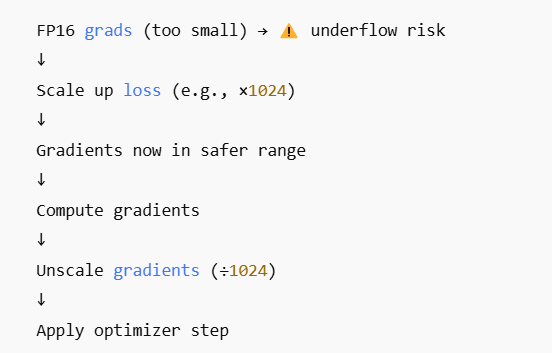
   
*   **PyTorch Implementation:**
    ```python
    import torch
    from torch.cuda.amp import autocast, GradScaler

    scaler = GradScaler()

    # Inside training loop
    optimizer.zero_grad()

    with autocast(): # Runs forward pass ops in lower precision where safe
        outputs = model(inputs)
        loss = criterion(outputs, targets)

    # Scales loss. Calls backward() on scaled loss to create scaled gradients.
    scaler.scale(loss).backward()

    # scaler.step() first unscales gradients of the optimizer's assigned params.
    # If gradients aren't inf/NaN, optimizer.step() is called.
    # Otherwise, optimizer.step() is skipped.
    scaler.step(optimizer)

    # Updates the scale for next iteration.
    scaler.update()
    ```
*   **Benefit:** Reduces memory for parameters (if model loaded in FP16), activations, and gradients. Speeds up training.

### **2. Gradient Accumulation:**

*   **Concept:** Simulate a larger batch size without increasing GPU memory usage. Process multiple smaller "micro-batches" sequentially, accumulate their gradients, and only perform the optimizer step after processing a desired number of micro-batches (forming a larger effective batch).
*   **How it works:** Perform forward and backward passes for a micro-batch, but *don't* call `optimizer.step()` or `optimizer.zero_grad()`. Repeat this for `accumulation_steps`. After the last micro-batch, call `optimizer.step()` to update weights using the accumulated gradients, then call `optimizer.zero_grad()`.
*   **PyTorch Implementation:**
    ```python
    accumulation_steps = 4 # Example: Effective batch size = micro_batch_size * 4
    effective_batch_size = micro_batch_size * accumulation_steps

    # Inside training loop (iterating over micro-batches)
    outputs = model(inputs) # Assuming inputs is a micro-batch
    loss = criterion(outputs, targets)
    loss = loss / accumulation_steps # Normalize loss for accumulation

    loss.backward() # Accumulate gradients

    if (step + 1) % accumulation_steps == 0:
        optimizer.step() # Update weights
        optimizer.zero_grad() # Reset gradients
    ```
*   **Benefit:** Achieves the training dynamics of a larger batch size while only needing memory for a single micro-batch's activations and gradients.

### **3. Gradient Checkpointing (Activation Checkpointing):**

*   **Concept:** Trade computation time for memory. Instead of storing all intermediate activations during the forward pass, only store a subset. During the backward pass, recompute the necessary activations on the fly for the segments where they weren't stored.
*   **How it works:** Wrap specific modules or code blocks (like transformer layers) with `torch.utils.checkpoint.checkpoint`. PyTorch handles the recomputation during backprop.
*   **PyTorch Implementation:**
    ```python
    import torch
    import torch.utils.checkpoint as checkpoint

    # Example within a model's forward method
    def forward(self, x):
        for layer in self.layers:
             # Instead of: x = layer(x)
             x = checkpoint.checkpoint(layer, x, use_reentrant=False) # use_reentrant=False is generally recommended
        return x
    ```
*   **Benefit:** Drastically reduces memory required for activations, often the largest consumer after parameters and optimizer states for large models/long sequences. Slows down training due to recomputation.

### **4. Model Parallelism & Sharding:**

*   **Concept:** Distribute the model, its gradients, and optimizer states across multiple GPUs (or even CPU RAM) instead of replicating the entire model on each GPU (like standard `DistributedDataParallel`).
*   **Techniques:**
    *   **Tensor Parallelism:** Splits individual large layers (like linear layers in Transformers) across GPUs. (e.g., Megatron-LM)
    *   **Pipeline Parallelism:** Assigns different layers of the model to different GPUs, forming a pipeline. Needs careful scheduling to minimize GPU idle time ("bubbles"). (e.g., GPipe)
    *   **Fully Sharded Data Parallel (FSDP):** A PyTorch native approach (`torch.distributed.fsdp.FullyShardedDataParallel`). Each DDP process only holds a *shard* of the model's parameters, gradients, and optimizer states. It gathers the necessary full layers only when needed for forward/backward computation. Can optionally offload shards to CPU.
    *   **DeepSpeed ZeRO (Zero Redundancy Optimizer):** A popular library that implements similar sharding ideas in stages:
        *   ZeRO Stage 1: Shards optimizer states.
        *   ZeRO Stage 2: Shards optimizer states and gradients.
        *   ZeRO Stage 3: Shards optimizer states, gradients, and model parameters.
        *   ZeRO-Offload: Offloads parts (optimizer states, parameters) to CPU RAM.
*   **PyTorch Implementation (FSDP example):**
    ```python
    import torch.distributed as dist
    from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
    from torch.distributed.fsdp.wrap import size_based_auto_wrap_policy
    import functools

    # Setup distributed environment (e.g., using torchrun)

    # Define a wrapping policy (e.g., wrap layers larger than 100M params)
    my_auto_wrap_policy = functools.partial(
        size_based_auto_wrap_policy, min_num_params=100_000_000
    )

    # Ensure model is on meta device or rank 0 CPU before wrapping
    model = model.to('meta') # Or load on rank 0 cpu then wrap

    model = FSDP(model, auto_wrap_policy=my_auto_wrap_policy, device_id=torch.cuda.current_device())
    # ... rest of the training loop using standard DDP practices ...
    ```
*   **Benefit:** Significantly reduces the peak memory required *per GPU*, allowing much larger models to be trained than would fit on a single device. Requires multiple GPUs. Libraries like Hugging Face `Accelerate` simplify using FSDP and DeepSpeed.

**5. CPU/Disk Offloading (with FSDP/DeepSpeed):**

* CPU Offloading: Transfer parts of the model or optimizer states to CPU memory when not in immediate use.​

* Disk Offloading: Store less frequently accessed data on disk, freeing up GPU memory.

*   **Concept:** Move parts of the model, gradients, or optimizer states temporarily to CPU RAM when they are not actively needed on the GPU.
*   **How it works:** Integrated into FSDP and DeepSpeed ZeRO configurations. You specify which components (parameters, optimizer states) can be offloaded.
*   **Benefit:** Frees up significant GPU VRAM, trading it for slower CPU RAM access and CPU-GPU data transfer overhead. Useful when even sharding isn't enough for available VRAM.

**6. Smaller Batch Size:**

*   **Concept:** The most straightforward approach. Reduce the number of samples processed in each forward/backward pass.
*   **Benefit:** Directly reduces memory needed for activations and temporary buffers.
*   **Drawback:** Can lead to noisier gradient updates, potentially slowing convergence or requiring learning rate adjustments. Often used in conjunction with Gradient Accumulation.

**Choosing Techniques:**

*   Start with **AMP** and **Gradient Accumulation**. These are relatively easy to implement and often provide substantial savings.
*   If memory is still an issue, especially activation memory, introduce **Gradient Checkpointing**.
*   For models that fundamentally don't fit on a single GPU even with the above, explore **FSDP** or **DeepSpeed ZeRO** (requires multiple GPUs or CPU offloading).
*   Use libraries like **Hugging Face `Accelerate`** which abstract away much of the complexity of AMP, Gradient Accumulation, DeepSpeed, and FSDP.




## Part 2: Handling Large Datasets Exceeding RAM in PyTorch

When your text dataset is too large to load into your machine's RAM, you need strategies to load and process it piece by piece. PyTorch's `Dataset` and `DataLoader` are designed for this.

**Core Idea:** The `Dataset` object should *not* load the entire dataset into memory at initialization. Instead, its `__getitem__(index)` method should load *only the single data point* (or a small related chunk) corresponding to the given index directly from disk or another source when requested by the `DataLoader`.

**Strategies using `Dataset` and `DataLoader`:**

**1. Indexing and Lazy Loading (Map-Style Datasets):**

*   **Concept:** Create an index of your data (e.g., file offsets, line numbers, filenames) that *does* fit into memory. When `__getitem__(idx)` is called, use the index to quickly locate and read only the required data item from the large file(s) on disk.
*   **Implementation (`torch.utils.data.Dataset`):**
    ```python
    import torch
    from torch.utils.data import Dataset, DataLoader
    import os

    class LargeTextDataset(Dataset):
        def __init__(self, data_file, index_file):
            self.data_file_path = data_file
            # Load or build an index (e.g., list of byte offsets for each line/document)
            # This index MUST fit in RAM.
            self.index = self._load_or_build_index(index_file)
            # Open the main data file handle here ONLY IF seeking is efficient
            # Otherwise, open it within __getitem__ (might be slower)
            # self.data_file = open(self.data_file_path, 'r', encoding='utf-8')

        def _load_or_build_index(self, index_file):
            # Logic to load pre-computed index or build it by scanning data_file once
            # Example: Store tuples of (start_byte, end_byte) for each sample
            index = []
            if os.path.exists(index_file):
                 # Load index from file
                 pass # Replace with actual loading logic
            else:
                 # Build index by iterating through data_file once
                 # Store byte offsets using file.tell()
                 # Save index to index_file for future use
                 pass # Replace with actual building/saving logic
            print(f"Built/Loaded index with {len(index)} entries.")
            return index # Should be a list or similar structure

        def __len__(self):
            return len(self.index)

        def __getitem__(self, idx):
            # Option 1: Re-open file each time (safer for multiprocessing, potentially slower)
            with open(self.data_file_path, 'r', encoding='utf-8') as f:
                start_byte, end_byte = self.index[idx]
                f.seek(start_byte)
                raw_text = f.read(end_byte - start_byte) # Read only the required chunk

            # Option 2: Use a persistent file handle (if created in __init__)
            # Be cautious with multiprocessing - file handles might not be fork-safe
            # self.data_file.seek(self.index[idx][0])
            # raw_text = self.data_file.read(self.index[idx][1] - self.index[idx][0])

            # --- Process the raw_text ---
            # Example: Tokenize the text
            # tokens = tokenizer(raw_text, ...)
            # return {'input_ids': tokens['input_ids'], ...}
            return raw_text # Return processed data (e.g., tokenized tensor)

        # Optional: If using persistent file handle, ensure it's closed
        # def __del__(self):
        #    if hasattr(self, 'data_file') and self.data_file:
        #        self.data_file.close()

    # --- Usage ---
    # dataset = LargeTextDataset('huge_corpus.txt', 'huge_corpus.idx')
    # dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
    # for batch in dataloader:
    #     # process batch on GPU
    ```
*   **Key:** `__getitem__` performs disk I/O for *one* sample. `DataLoader` with `num_workers > 0` will run multiple `__getitem__` calls in parallel background processes, fetching data while the GPU computes.

**2. Streaming / Iterating (Iterable-Style Datasets):**

*   **Concept:** Use when the dataset is naturally a stream (e.g., reading lines from a massive file, web stream) or when random access (required by `__getitem__`) is inefficient or impossible. The dataset object itself acts as an iterator.
*   **Implementation (`torch.utils.data.IterableDataset`):**
    ```python
    import torch
    from torch.utils.data import IterableDataset, DataLoader
    import itertools

    class StreamingTextDataset(IterableDataset):
        def __init__(self, data_file, tokenizer):
            super().__init__()
            self.data_file = data_file
            self.tokenizer = tokenizer

        def _process_line(self, line):
            # Basic tokenization example
            # tokens = self.tokenizer(line.strip(), ...)
            # return {'input_ids': tokens['input_ids'], ...}
            return line.strip() # Return processed data

        def __iter__(self):
            # Create an iterator for the data file
            file_itr = open(self.data_file, 'r', encoding='utf-8')

            # --- Handling multiprocessing (num_workers > 0) ---
            # Each worker needs to process a different shard of the data.
            worker_info = torch.utils.data.get_worker_info()
            if worker_info is None: # Single-process data loading
                iter_start = 0
                iter_end = float('inf') # Or read the whole file
            else: # Multiple workers
                # Simple sharding: Split lines across workers
                per_worker = int(math.ceil( ESTIMATED_LINES / float(worker_info.num_workers)))
                worker_id = worker_info.id
                iter_start = worker_id * per_worker
                iter_end = min(iter_start + per_worker, ESTIMATED_LINES) # Needs line count estimate or more robust sharding

                # More robust: Use itertools.islice or similar
                # file_itr = itertools.islice(file_itr, worker_id, None, worker_info.num_workers) # Process every N-th line

            # Example using islice (simpler if line count unknown) - Processes every Nth line
            if worker_info:
                 file_itr = itertools.islice(file_itr, worker_info.id, None, worker_info.num_workers)

            # Map the processing function over the iterator
            # Use yield to make it a generator
            # Add .close() in a finally block if needed
            try:
                mapped_itr = map(self._process_line, file_itr)
                yield from mapped_itr
            finally:
                if hasattr(file_itr, 'close'):
                    file_itr.close()


    # --- Usage ---
    # dataset = StreamingTextDataset('huge_corpus.txt', tokenizer)
    # Note: shuffle=True doesn't work well with basic IterableDatasets. Requires buffer shuffling.
    # dataloader = DataLoader(dataset, batch_size=32, num_workers=4)
    # for batch in dataloader:
    #     # process batch
    ```
*   **Key:** `__iter__` returns a generator that yields processed data points one by one. Handling multiprocessing (`num_workers > 0`) requires explicitly sharding the data stream across workers within `__iter__`. Shuffling is trickier than with map-style datasets.

**3. Using Specialized Libraries:**

*   **Hugging Face `datasets`:** Highly recommended for NLP. It uses Apache Arrow memory mapping behind the scenes, which efficiently handles datasets larger than RAM. It provides lazy loading, caching, streaming, and powerful preprocessing capabilities.
    ```python
    from datasets import load_dataset

    # Load dataset (potentially streaming from Hub or local files)
    # Use streaming=True for datasets that truly don't fit even on disk cache easily
    dataset = load_dataset('text', data_files={'train': 'huge_corpus.txt'}, streaming=False) # streaming=False uses caching

    # Apply tokenization (lazy - processed on the fly or cached)
    def tokenize_function(examples):
        return tokenizer(examples["text"], ...) # Configure padding/truncation

    tokenized_datasets = dataset.map(tokenize_function, batched=True, num_proc=4) # num_proc for parallel processing
    tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask'])

    # Use directly with DataLoader
    dataloader = DataLoader(tokenized_datasets['train'], batch_size=32, shuffle=True, num_workers=0) # Often num_workers=0 is fine with datasets' parallelism
    ```
*   **`torchdata` (DataPipes):** PyTorch's newer library for building composable data loading pipelines. Offers more flexibility than traditional Datasets/DataLoaders, including better support for streaming and combining data sources. Still evolving but powerful.
*   **WebDataset:** Optimized for datasets stored as `.tar` archives, especially useful for large image-text datasets. Streams data directly from archives.

**4. Memory-Mapped Files:**

*   **Concept:** Use libraries like `numpy.memmap` if your *processed* data (e.g., token IDs) can be stored as a large numerical array on disk. This maps the file into virtual memory, allowing you to access slices as if they were in RAM, while the OS handles loading pages from disk as needed.
*   **Implementation:** Preprocess the data into a NumPy array, save it with `np.save`. Load it back using `np.load(filename, mmap_mode='r')`. Create a PyTorch `Dataset` that wraps this memory-mapped array and returns `torch.from_numpy()` slices in `__getitem__`.

**DataLoader Optimizations:**

*   **`num_workers`:** Set `num_workers` > 0 in `DataLoader`. This uses separate processes to load data in parallel, hiding I/O latency. The optimal number depends on CPU cores, disk speed, and data processing complexity (often 4, 8, or more). Experiment is key.
*   **`pin_memory=True`:** If using GPUs, set `pin_memory=True`. This allocates the tensors returned by the `DataLoader` in pinned (page-locked) host memory, which speeds up the transfer from CPU RAM to GPU VRAM. Ensure you have enough non-swappable RAM.
*   **`prefetch_factor` (PyTorch >= 1.7):** Controls how many batches per worker are pre-fetched. Can sometimes help smooth out data loading performance. `prefetch_factor=2` (the default) is usually fine.

**Preprocessing Strategy:**

*   **Offline Preprocessing:** For complex preprocessing (like tokenization), it's almost always better to do it *once* offline and save the processed data (e.g., token IDs, attention masks) to disk. Your `Dataset` then just loads these pre-computed features, making `__getitem__` much faster (mostly just disk reads). This works very well with the Indexing or Memory-Mapped File approaches, or using libraries like `datasets` which handle caching automatically.
*   **On-the-Fly Preprocessing:** If preprocessing is very simple or needs to be dynamic, perform it within `__getitem__` or using `DataLoader`'s `collate_fn`. Be aware this can become a bottleneck if complex, potentially requiring more `num_workers`.

By combining these memory-saving training techniques and efficient data loading strategies, you can tackle training large language models and processing massive datasets even with hardware limitations.